This notebook takes the CDL in radar coordinates (produced by the ungeo_cropscape.ipynb notebook), and combines similar surface types into a "road mask" file, where roads/barren/stable areas have value 1, and crops/vegetated areas/open water/etc have value 0. 
<br>
<br>
Use the "earthscope_insar" conda environment as the Python kernel.
***

In [14]:
# import necessary packages
import os, glob
from osgeo import gdal
import math
import numpy as np
import matplotlib.pyplot as plt

In [7]:
workdir = './' 

# size of entire SLC
az0 = 0
daz= 1575
rg0 = 0
drg = 9000

In [10]:
# load median amplitude file IF THIS EXISTS, it is a way to filter out some pixels that are super dark.
# ds = gdal.Open(workdir+"ampmed.r4", gdal.GA_ReadOnly)
# ampmed = ds.GetRasterBand(1).ReadAsArray()

ampcoharray = np.ones(([daz,drg]))
# for i in range(0,daz):
#     for j in range(0,drg):
#         # if the pixel is SUPER dark, don't let it be considered a good road pixel.
#         if np.logical_and(ampmed[i,j]<50):
#             ampcoharray[i,j] = 0

In [9]:
# construct road array 
# Kelly produced this mask so she could then remove these pixels and segment the remaining fields
CDLdates=np.arange(2023,2024,1)
CDLnd = len(CDLdates) # for us, this is 1 but can be used with many CDLs, will loop over them. 
allcrops = np.ndarray([daz,drg,CDLnd])

for k in np.arange(CDLnd): #loop through subsequent SLC pairs
    ds = gdal.Open(workdir+"/radarfullres/CDL_"+str(CDLdates[k])+"_clip_20240705112914_227417551.tif", gdal.GA_ReadOnly)
    allcrops[:,:,k] = ds.GetRasterBand(1).ReadAsArray(rg0,az0,drg,daz)

# specific land cover type codes are either road or crop.
# road -> 1
# crop -> 0 ??

roadarray0 = np.zeros(([daz,drg,CDLnd]))
roadarray0[(allcrops>120)&(allcrops<125)] = 1
roadarray0[allcrops==131] = 1
roadarray0[allcrops==65]=1

allfallow=np.zeros(([daz,drg,CDLnd]))
allfallow[allcrops==61]=1
allfallow=np.sum(allfallow,2)
alwaysfallow=np.zeros(([daz,drg]))
alwaysfallow[allfallow==CDLnd]=1

roadarray1=np.sum(roadarray0,2)
#uncomment below if you want to include things that are always fallow
roadarray1[alwaysfallow==1]=1
roadarray = (roadarray1>0)*1.0

In [11]:
roadarray = roadarray*ampcoharray

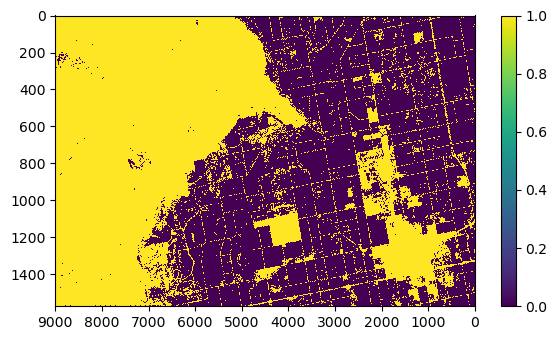

In [21]:
plt.figure(figsize=(6,3.5),tight_layout=True)
plt.imshow(roadarray,vmin=0,vmax=1,aspect='auto',interpolation='none')
plt.colorbar()
plt.xlim(drg,0)
plt.show()

In [ ]:
# writes the file
driver=gdal.GetDriverByName('ISCE')
colds = driver.Create(workdir+'roadarray_test.r4',drg,daz,1,gdal.GDT_Float32)
colds.GetRasterBand(1).WriteArray(roadarray)
colds=None

# NOTE
# this will not necessarily be exactly the same as the roadarray.r4 file used in the study.
# the one used in the study was created using multiple years' worth of CDL images by coauthor Kelly Devlin
# and she eliminated very dark pixels from further analysis 
# but this is very similar and shows how you can create the roadarray.r4 mask file.